In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Đọc dữ liệu

merged_giai-tri.jsonl
news_data_1776009152_part1_spider_vnexpress_bot1.jsonl
news_data_1776009152_part2_spider_vnexpress_bot1.jsonl
news_data_1776067573_part1_spider_vnexpress_bot1.jsonl
news_data_1776067573_part2_spider_vnexpress_bot1.jsonl
news_data_1776070515_part1_spider_vnexpress_bot1.jsonl
news_data_1776070515_part2_spider_vnexpress_bot1.jsonl
news_data_1776070728_part1_spider_vnexpress_bot1.jsonl
news_data_1776070728_part2_spider_vnexpress_bot1.jsonl
news_data_1776142495_part1_spider_vnexpress_bot1.jsonl
news_data_1776142495_part2_spider_vnexpress_bot1.jsonl


In [3]:
RAW_DATA_PATH = "../../data/data-needed"

data_files: list[str] = os.listdir(RAW_DATA_PATH)
print("Các file dữ liệu có trong thư mục:", data_files)

data = []
for file in data_files:
    with open(os.path.join(RAW_DATA_PATH, file), "r", encoding="utf-8") as f:
        # Dùng List Comprehension để code ngắn gọn và chạy nhanh hơn
        data.extend([json.loads(line) for line in f])

# Bước 2: "Làm phẳng" (Flatten) dữ liệu lồng nhau
df = pd.json_normalize(data)

# Kiểm tra kết quả
print(df.head())

Các file dữ liệu có trong thư mục: ['merged_giai-tri.jsonl', 'news_data_1776009152_part1_spider_vnexpress_bot1.jsonl', 'news_data_1776009152_part2_spider_vnexpress_bot1.jsonl', 'news_data_1776067573_part1_spider_vnexpress_bot1.jsonl', 'news_data_1776067573_part2_spider_vnexpress_bot1.jsonl', 'news_data_1776070515_part1_spider_vnexpress_bot1.jsonl', 'news_data_1776070515_part2_spider_vnexpress_bot1.jsonl', 'news_data_1776070728_part1_spider_vnexpress_bot1.jsonl', 'news_data_1776070728_part2_spider_vnexpress_bot1.jsonl', 'news_data_1776142495_part1_spider_vnexpress_bot1.jsonl', 'news_data_1776142495_part2_spider_vnexpress_bot1.jsonl']
  metadata.doc_id metadata.source_name  \
0         5060048            VnExpress   
1         5059160            VnExpress   
2         5058945            VnExpress   
3         5059903            VnExpress   
4         5059447            VnExpress   

                                 metadata.source_url  \
0  https://vnexpress.net/nha-tho-nguyen-duc-mau-q.

--- Thông tin tập dữ liệu ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3494 entries, 0 to 3493
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   metadata.doc_id             3494 non-null   object
 1   metadata.source_name        3494 non-null   object
 2   metadata.source_url         3494 non-null   object
 3   metadata.publish_date       3135 non-null   object
 4   metadata.author             3494 non-null   object
 5   content.title               3479 non-null   object
 6   content.sapo                3479 non-null   object
 7   content.content             3494 non-null   object
 8   content.word_count          3494 non-null   int64 
 9   labeling.original_category  3494 non-null   object
 10  labeling.target_label       3494 non-null   object
 11  labeling.tags               3494 non-null   object
 12  labeling.is_multilabel      3494 non-null   bool  
 13  labeling.crawl_top

C:\Users\ACER\AppData\Local\Temp\ipykernel_4444\3728927120.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='labeling.target_label', palette='viridis')


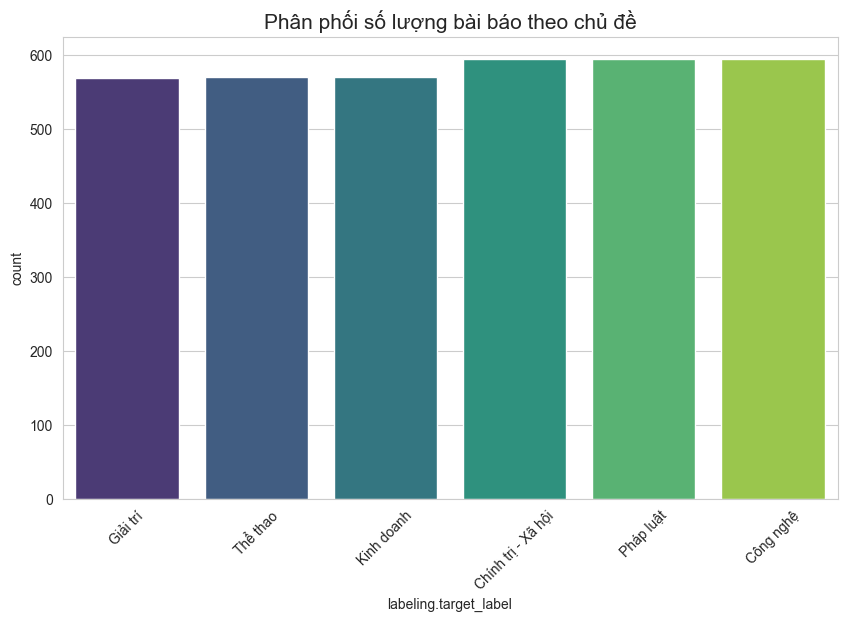

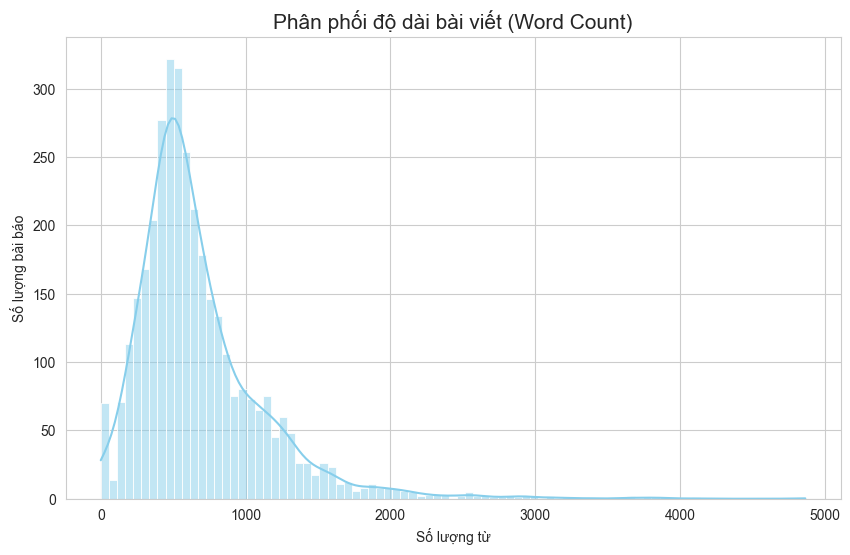

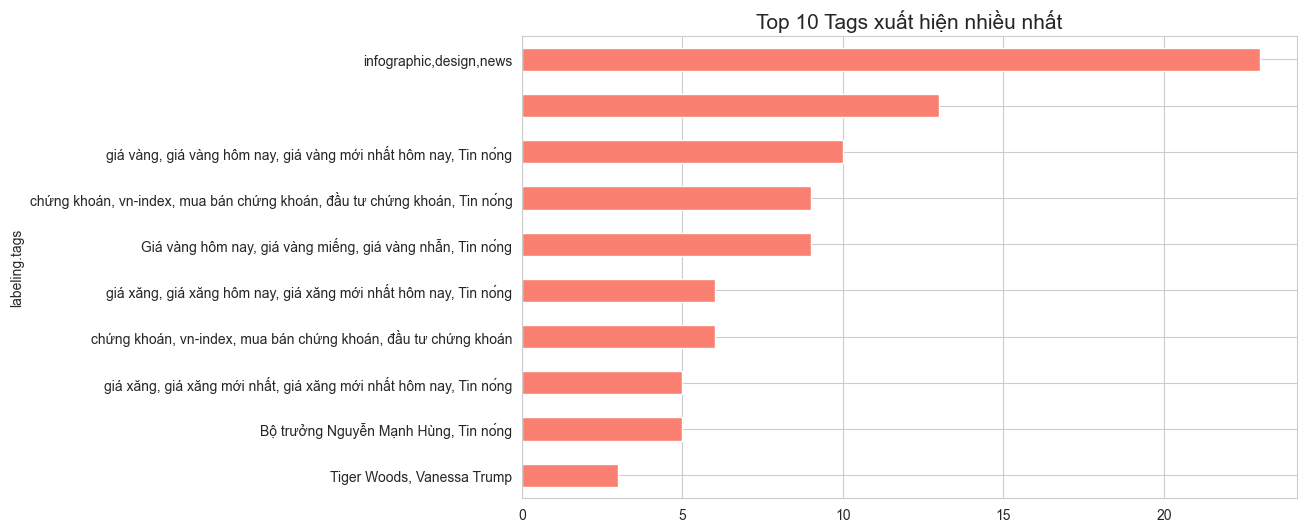

In [4]:
# 3. Tổng quan dữ liệu cơ bản
print("--- Thông tin tập dữ liệu ---")
print(df.info())
print("\n--- Thống kê số lượng theo nhãn ---")
print(df['labeling.target_label'].value_counts())

# 4. Vẽ biểu đồ phân phối nhãn (Class Distribution)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.countplot(data=df, x='labeling.target_label', palette='viridis')
plt.title('Phân phối số lượng bài báo theo chủ đề', fontsize=15)
plt.xticks(rotation=45)
plt.show()

# 5. Vẽ biểu đồ phân phối số lượng từ (Word Count Distribution)
plt.figure(figsize=(10, 6))
sns.histplot(df['content.word_count'], kde=True, color='skyblue')
plt.title('Phân phối độ dài bài viết (Word Count)', fontsize=15)
plt.xlabel('Số lượng từ')
plt.ylabel('Số lượng bài báo')
plt.show()

# 6. Thống kê Tags (Xử lý cột danh sách)
all_tags = df['labeling.tags'].explode() # Giải nén list tags thành các dòng riêng lẻ
top_tags = all_tags.value_counts().head(10)

plt.figure(figsize=(10, 6))
top_tags.plot(kind='barh', color='salmon')
plt.gca().invert_yaxis()
plt.title('Top 10 Tags xuất hiện nhiều nhất', fontsize=15)
plt.show()